# NYC 311 Heating Requests: Resolution-Time EDA

**Goal.** Predict how long a heating request takes to resolve (`Closed Date` minus `Created Date`).

**Source.** NYC 311 Service Requests, 2020 to 2026-10-01 (22.67 M rows, 16 GB CSV).

**Plan for this notebook.**
1. Show where heating sits among the biggest complaint categories.
2. Keep only heating requests and show exactly what was removed.
3. Continue the EDA on the heating-only dataset (structure, cleaning, univariate, bivariate, multivariate, decision table).

## 0. Setup

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

In [2]:
CSV_PATH = Path("311_Service_Requests_from_2020_to_Present_20261003.csv")
DATA_DIR = Path("data")
FIG_DIR = Path("figures")
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

COUNTS_CACHE = DATA_DIR / "category_counts.csv"
HEATING_PARQUET = DATA_DIR / "heating_raw.parquet"

CATEGORY_COL = "Problem (formerly Complaint Type)"
HEATING_CATEGORY = "HEAT/HOT WATER"

**Figure style (Lecture 2).** Serif font, labelled axes with units, bars sorted by value, a zero baseline,
a caption instead of a title, and the Okabe-Ito colour-blind-safe palette.
The highlighted bar also carries a hatch pattern, so it never relies on hue alone.

In [3]:
GREY = "#8C8C8C"
VERMILION = "#D55E00"
BLUE = "#0072B2"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
})

In [4]:
def add_caption(fig, text, y=-0.04):
    """Put the figure caption under the figure, left-aligned (papers use captions, not titles)."""
    fig.text(0.01, y, text, ha="left", va="top", fontsize=11, wrap=True)


def tidy_label(category):
    """Turn 'NOISE - RESIDENTIAL' into 'Noise - Residential' for display."""
    return category.title()

## 1. Which complaint categories dominate NYC 311?

**Question the figure answers:** *Which five complaint categories receive the most requests, and where does heating rank?*

One thing to fix before counting. The raw column spells some labels two ways (`HEAT/HOT WATER` and `Heat/Hot Water`).
Counting on the upper-cased, trimmed label keeps one category from being split in two.

In [5]:
def load_category_counts():
    """Rows per complaint category. Cached, because scanning the 16 GB CSV takes about 90 seconds."""
    if COUNTS_CACHE.exists():
        return pd.read_csv(COUNTS_CACHE)

    query = f"""
        SELECT upper(trim("{CATEGORY_COL}")) AS category, count(*) AS n
        FROM read_csv('{CSV_PATH}', header=true, all_varchar=true, ignore_errors=true, sample_size=-1)
        GROUP BY 1
        ORDER BY n DESC
    """
    counts = duckdb.connect().execute(query).df()
    counts.to_csv(COUNTS_CACHE, index=False)
    return counts


counts = load_category_counts()
TOTAL_ROWS = int(counts["n"].sum())
print(f"{TOTAL_ROWS:,} requests across {len(counts)} complaint categories")
counts.head(8)

22,671,531 requests across 261 complaint categories


,category,n
0,ILLEGAL PARKING,2948820
1,NOISE - RESIDENTIAL,2570655
2,HEAT/HOT WATER,1656653
3,NOISE - STREET/SIDEWALK,1172503
4,BLOCKED DRIVEWAY,1081959
5,UNSANITARY CONDITION,713539
6,REQUEST LARGE BULKY ITEM COLLECTION,632148
7,STREET CONDITION,517738


In [6]:
TOP_N = 5
top = counts.head(TOP_N).copy()
top["share"] = top["n"] / TOTAL_ROWS * 100
top["is_heating"] = top["category"] == HEATING_CATEGORY

heating_rank = int(counts.index[counts["category"] == HEATING_CATEGORY][0]) + 1
print(f"Heating ranks #{heating_rank} of {len(counts)} categories")

Heating ranks #3 of 261 categories


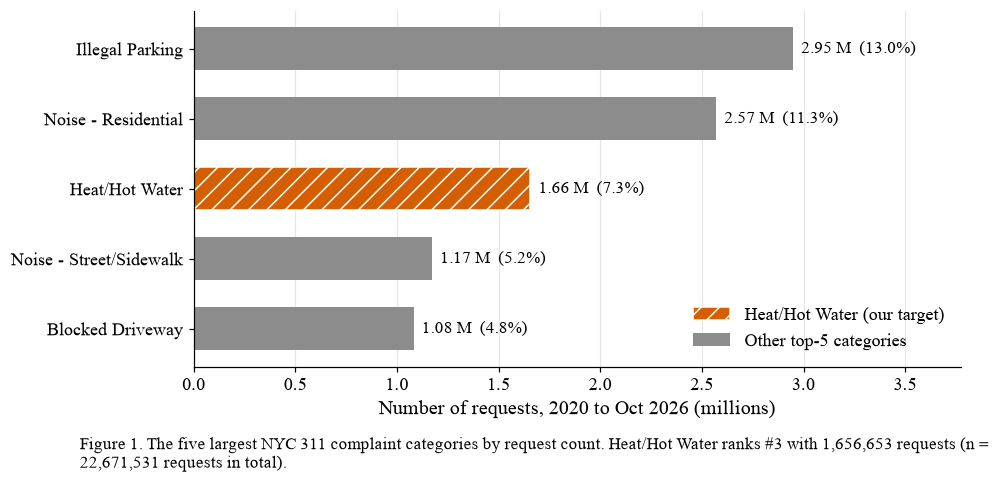

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))

# Largest category on top: reverse so barh draws it last.
plot_df = top.iloc[::-1]
colors = [VERMILION if flag else GREY for flag in plot_df["is_heating"]]
bars = ax.barh(
    [tidy_label(c) for c in plot_df["category"]],
    plot_df["n"] / 1e6,
    color=colors,
    height=0.62,
)

for bar, flag in zip(bars, plot_df["is_heating"]):
    if flag:
        bar.set_hatch("//")
        bar.set_edgecolor("white")

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    label = f"{row['n'] / 1e6:.2f} M  ({row['share']:.1f}%)"
    ax.text(bar.get_width() + 0.04, bar.get_y() + bar.get_height() / 2, label, va="center", fontsize=11)

ax.set_xlim(0, top["n"].max() / 1e6 * 1.28)
ax.set_xlabel("Number of requests, 2020 to Oct 2026 (millions)")
ax.grid(axis="y", visible=False)
ax.legend(
    handles=[
        Patch(facecolor=VERMILION, hatch="//", edgecolor="white", label="Heat/Hot Water (our target)"),
        Patch(facecolor=GREY, label="Other top-5 categories"),
    ],
    loc="lower right",
)

add_caption(
    fig,
    f"Figure 1. The five largest NYC 311 complaint categories by request count. "
    f"Heat/Hot Water ranks #{heating_rank} with {top.loc[top['is_heating'], 'n'].iloc[0]:,} requests "
    f"(n = {TOTAL_ROWS:,} requests in total).",
)
fig.savefig(FIG_DIR / "01_top5_categories.png")
plt.show()

**Reading Figure 1.** Heating is the third-largest complaint category in the whole city, ahead of street noise and blocked driveways.
It is large enough to model on its own, and it comes from a single agency (HPD) with a single, well-defined resolution process.

## 2. Keep only heating requests

**Decision.** Keep rows where the upper-cased `Problem` equals `HEAT/HOT WATER`. Drop every other row.

**Why.**
- The project predicts heating resolution time only. Other categories have different agencies, processes and timescales, so mixing them would blur the target.
- Matching on the upper-cased label keeps the 1,814 rows that were typed `Heat/Hot Water` in Aug to Oct 2023.
- `Non-Residential Heat` (DOHMH) is a different category with a different process, so this rule removes it too.

**How.** DuckDB filters the 16 GB file and writes the kept rows to Parquet. Every column stays as raw text for now,
because type conversion is a cleaning step we do later and document there.

In [8]:
def extract_heating_rows():
    """Filter the big CSV down to heating rows once and cache them as Parquet."""
    if HEATING_PARQUET.exists():
        return

    query = f"""
        COPY (
            SELECT *
            FROM read_csv('{CSV_PATH}', header=true, all_varchar=true, ignore_errors=true, sample_size=-1)
            WHERE upper(trim("{CATEGORY_COL}")) = '{HEATING_CATEGORY}'
        ) TO '{HEATING_PARQUET}' (FORMAT parquet)
    """
    duckdb.connect().execute(query)


extract_heating_rows()
heating = pd.read_parquet(HEATING_PARQUET)
print(f"Kept {len(heating):,} rows x {heating.shape[1]} columns")

Kept 1,656,653 rows x 44 columns


In [9]:
expected = int(counts.loc[counts["category"] == HEATING_CATEGORY, "n"].iloc[0])
assert len(heating) == expected, f"row count {len(heating):,} does not match category count {expected:,}"

kept = len(heating)
dropped = TOTAL_ROWS - kept
print(f"Before: {TOTAL_ROWS:,} rows")
print(f"After:  {kept:,} rows ({kept / TOTAL_ROWS * 100:.1f}% kept)")
print(f"Dropped: {dropped:,} rows from {len(counts) - 1} other categories")

Before: 22,671,531 rows
After:  1,656,653 rows (7.3% kept)
Dropped: 21,014,878 rows from 260 other categories


### Before and after

**Question the figure answers:** *How many rows did the filter remove, and which categories did they come from?*

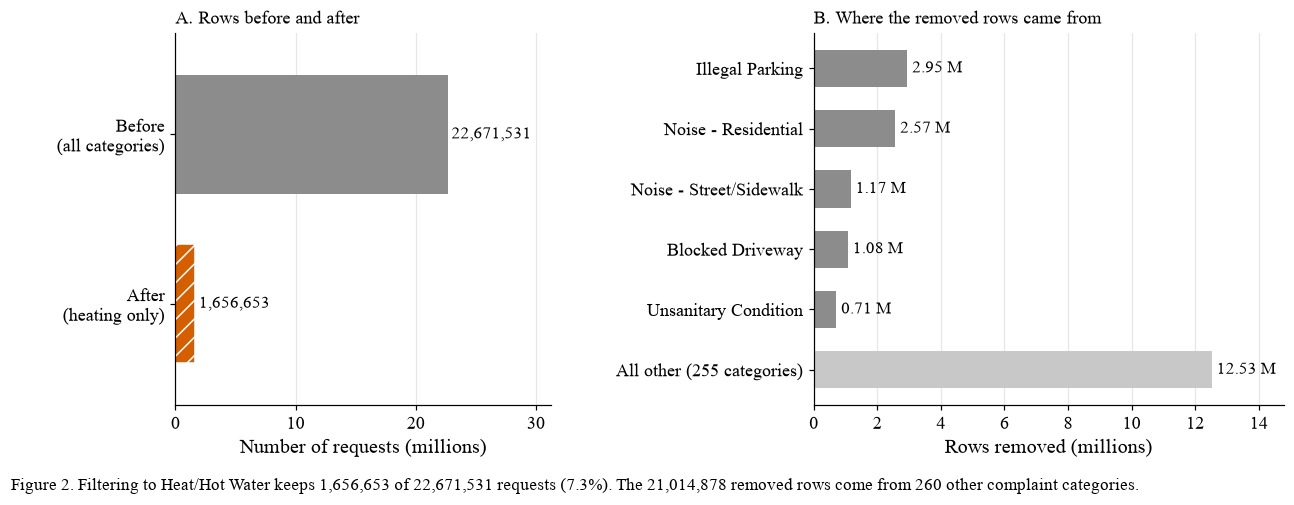

In [10]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1, 1.25], "wspace": 0.62})

# Panel A: row count before and after, zero baseline.
ax_a.barh(
    ["After\n(heating only)", "Before\n(all categories)"],
    [kept / 1e6, TOTAL_ROWS / 1e6],
    color=[VERMILION, GREY],
    height=0.7,
)
ax_a.patches[0].set_hatch("//")
ax_a.patches[0].set_edgecolor("white")
for patch, value in zip(ax_a.patches, [kept, TOTAL_ROWS]):
    ax_a.text(patch.get_width() + 0.3, patch.get_y() + patch.get_height() / 2, f"{value:,}", va="center", fontsize=11)
ax_a.set_xlim(0, TOTAL_ROWS / 1e6 * 1.38)
ax_a.set_ylim(-0.6, 1.6)
ax_a.set_xlabel("Number of requests (millions)")
ax_a.grid(axis="y", visible=False)
ax_a.set_title("A. Rows before and after", loc="left", fontsize=12)

# Panel B: what was removed, largest first, 'all other' last.
removed = counts[counts["category"] != HEATING_CATEGORY].copy()
largest = removed.head(5)
rest = removed.iloc[5:]["n"].sum()
labels = [tidy_label(c) for c in largest["category"]] + [f"All other ({len(removed) - 5} categories)"]
values = list(largest["n"] / 1e6) + [rest / 1e6]
bar_colors = [GREY] * 5 + ["#C8C8C8"]

positions = np.arange(len(labels))[::-1]
ax_b.barh(positions, values, color=bar_colors, height=0.62)
ax_b.set_yticks(positions)
ax_b.set_yticklabels(labels)
for pos, value in zip(positions, values):
    ax_b.text(value + 0.15, pos, f"{value:.2f} M", va="center", fontsize=11)
ax_b.set_xlim(0, max(values) * 1.18)
ax_b.set_xlabel("Rows removed (millions)")
ax_b.grid(axis="y", visible=False)
ax_b.set_title("B. Where the removed rows came from", loc="left", fontsize=12)

add_caption(
    fig,
    f"Figure 2. Filtering to Heat/Hot Water keeps {kept:,} of {TOTAL_ROWS:,} requests ({kept / TOTAL_ROWS * 100:.1f}%). "
    f"The {dropped:,} removed rows come from {len(removed)} other complaint categories.",
)
fig.savefig(FIG_DIR / "02_filter_to_heating_before_after.png")
plt.show()

## 3. The heating-only dataset

From here on, `heating` is the working dataset. First look at its structure.

In [11]:
heating.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,70607308,10/01/2026 11:58:54 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,NO HOT WATER,RESIDENTIAL BUILDING,10467,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.87711548073,-73.87314137787,POINT (-73.873141377875 40.877115480725)
1,70615467,10/01/2026 11:41:10 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,11355,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.75423566298,-73.83142702295,POINT (-73.831427022953 40.754235662982)
2,70613895,10/01/2026 11:31:41 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,10019,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.76830976173,-73.98662439013,POINT (-73.986624390128 40.76830976173)
3,70608878,10/01/2026 11:31:30 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,11226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.65595860808,-73.95490586002,POINT (-73.954905860019 40.655958608083)
4,70608877,10/01/2026 11:26:06 PM,NaN,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,10032,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.82946158953,-73.94079691863,POINT (-73.940796918633 40.829461589532)


In [12]:
heating.shape

(1656653, 44)

## 4. Cleaning step 1: redundant structure

**Question this step answers:** *Which columns and rows add nothing, so they can go before we analyse anything?*

Order matters (Lecture 4): **drop the ID column first**, because a unique ID makes `duplicated()` unable to ever fire.
Then count and drop duplicate rows. Then drop columns that hold a single value, columns that are exact copies of another column, and columns that can be rebuilt from another column.

### 4.1 The ID column: `Unique Key`

`Unique Key` is a serial number NYC assigns to every request. It carries no information about resolution time,
and it hides duplicates, because two otherwise identical requests still get different keys.

In [13]:
ID_COL = "Unique Key"

print(f"{ID_COL}: {heating[ID_COL].nunique():,} distinct values for {len(heating):,} rows, so every row has its own ID")
print(f"duplicated() with the ID:    {heating.duplicated().sum():,}")
print(f"duplicated() without the ID: {heating.drop(columns=[ID_COL]).duplicated().sum():,}")

Unique Key: 1,656,653 distinct values for 1,656,653 rows, so every row has its own ID


duplicated() with the ID:    0


duplicated() without the ID: 3,128


**Decision.** Drop `Unique Key`. The check above shows why: with the ID the duplicate count is 0, without it the real count appears.
`clean` is the working copy from here on; `heating` stays untouched as the "before" reference for every before/after figure.

In [14]:
clean = heating.drop(columns=[ID_COL])
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

clean: 1,656,653 rows x 43 columns


### 4.2 Duplicate rows

A row is an **exact duplicate** when every remaining column matches an earlier row, down to the second in `Created Date` and `Closed Date`.
`keep="first"` keeps one copy of each. Because the copies are identical, it does not matter which one is kept.

In [15]:
DATE_FORMAT = "%m/%d/%Y %I:%M:%S %p"
CHANNEL_COL = "Open Data Channel Type"


def resolution_hours(frame):
    """Hours between Created Date and Closed Date. Only used here to check what a drop does to the target."""
    created = pd.to_datetime(frame["Created Date"], format=DATE_FORMAT)
    closed = pd.to_datetime(frame["Closed Date"], format=DATE_FORMAT)
    return (closed - created).dt.total_seconds() / 3600

In [16]:
is_duplicate = clean.duplicated(keep="first")
n_duplicates = int(is_duplicate.sum())
all_copies = clean[clean.duplicated(keep=False)]

group_sizes = all_copies.groupby(list(all_copies.columns), dropna=False).size()
size_table = group_sizes.value_counts().sort_index().rename_axis("copies of the same row").rename("groups")

print(f"Exact duplicate rows to remove: {n_duplicates:,} ({n_duplicates / len(clean) * 100:.2f}% of rows)")
print(f"Rows involved, including the copy we keep: {len(all_copies):,} in {len(group_sizes):,} groups")
size_table

Exact duplicate rows to remove: 3,128 (0.19% of rows)
Rows involved, including the copy we keep: 6,160 in 3,032 groups


copies of the same row
2    2942
3      85
4       4
5       1
Name: groups, dtype: int64

**Are these real duplicates or two genuine complaints?** The same request submitted twice in the same second is a double-tap on "submit".
Two different tenants filing at the very same second, for the same address, with the same answer and close time, would be a coincidence.
If these are double-taps, the mobile app should be heavily over-represented among them.

In [17]:
channel_all = clean[CHANNEL_COL].value_counts(normalize=True) * 100
channel_removed = clean.loc[is_duplicate, CHANNEL_COL].value_counts(normalize=True) * 100
channel_removed = channel_removed.reindex(channel_all.index, fill_value=0)

channel_table = pd.DataFrame({"all rows (%)": channel_all.round(1), "removed duplicates (%)": channel_removed.round(1)})
channel_table

,all rows (%),removed duplicates (%)
Open Data Channel Type,,
ONLINE,53.7,28.3
PHONE,28.1,2.1
MOBILE,18.2,69.6


**Decision.** Drop the exact duplicates, keeping the first copy.

**Why.** They are repeated submissions of one request, and keeping them would count that request twice in every average and model fit.

**Not dropped.** Rows that match on address and creation second but differ elsewhere (for example a different `Closed Date`) are
different complaints, such as separate apartments in one building. We cannot tell them apart from the data, so they stay.

In [18]:
rows_before = len(clean)
hours_before = resolution_hours(clean)

clean = clean[~is_duplicate].reset_index(drop=True)
hours_after = hours_before[~is_duplicate]

assert clean.duplicated().sum() == 0
assert rows_before - len(clean) == n_duplicates
print(f"{rows_before:,} rows -> {len(clean):,} rows (removed {n_duplicates:,})")

1,656,653 rows -> 1,653,525 rows (removed 3,128)


### Before and after

**Question the figure answers:** *Which rows did the duplicate drop remove, and did it change the target?*

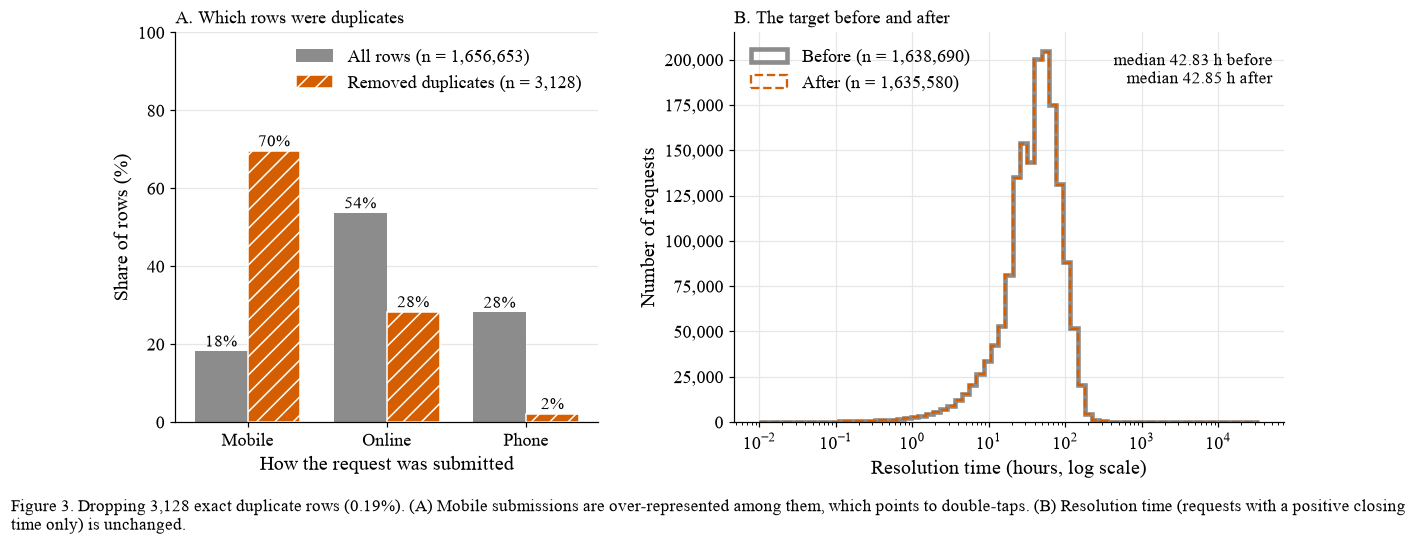

In [19]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.3], "wspace": 0.28})

# Panel A: channel mix of the removed rows against all rows, same zero baseline.
order = list(channel_removed.sort_values(ascending=False).index)
positions = np.arange(len(order))
bar_width = 0.38

ax_a.bar(positions - bar_width / 2, [channel_all[c] for c in order], bar_width, color=GREY)
ax_a.bar(
    positions + bar_width / 2,
    [channel_removed[c] for c in order],
    bar_width,
    color=VERMILION,
    hatch="//",
    edgecolor="white",
)
for pos, channel in zip(positions, order):
    ax_a.text(pos - bar_width / 2, channel_all[channel] + 1.2, f"{channel_all[channel]:.0f}%", ha="center", fontsize=11)
    ax_a.text(pos + bar_width / 2, channel_removed[channel] + 1.2, f"{channel_removed[channel]:.0f}%", ha="center", fontsize=11)

ax_a.set_xticks(positions)
ax_a.set_xticklabels([c.title() for c in order])
ax_a.set_ylim(0, 100)
ax_a.set_ylabel("Share of rows (%)")
ax_a.set_xlabel("How the request was submitted")
ax_a.grid(axis="x", visible=False)
ax_a.set_title("A. Which rows were duplicates", loc="left", fontsize=12)
ax_a.legend(
    handles=[
        Patch(facecolor=GREY, label=f"All rows (n = {rows_before:,})"),
        Patch(facecolor=VERMILION, hatch="//", edgecolor="white", label=f"Removed duplicates (n = {n_duplicates:,})"),
    ],
    loc="upper right",
)

# Panel B: resolution time before and after, one axis so the curves can be compared directly.
positive_before = hours_before[hours_before > 0].dropna()
positive_after = hours_after[hours_after > 0].dropna()
bins = np.logspace(-2, np.log10(positive_before.max()), 70)

ax_b.hist(positive_before, bins=bins, histtype="step", color=GREY, linewidth=3.0, label=f"Before (n = {len(positive_before):,})")
ax_b.hist(positive_after, bins=bins, histtype="step", color=VERMILION, linewidth=1.5, linestyle="--", label=f"After (n = {len(positive_after):,})")
ax_b.set_xscale("log")
ax_b.set_xlabel("Resolution time (hours, log scale)")
ax_b.set_ylabel("Number of requests")
ax_b.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax_b.set_title("B. The target before and after", loc="left", fontsize=12)
ax_b.legend(loc="upper left")
ax_b.text(
    0.98,
    0.95,
    f"median {positive_before.median():.2f} h before\nmedian {positive_after.median():.2f} h after",
    transform=ax_b.transAxes,
    ha="right",
    va="top",
    fontsize=11,
)

add_caption(
    fig,
    f"Figure 3. Dropping {n_duplicates:,} exact duplicate rows ({n_duplicates / rows_before * 100:.2f}%). "
    f"(A) Mobile submissions are over-represented among them, which points to double-taps. "
    f"(B) Resolution time (requests with a positive closing time only) is unchanged.",
)
fig.savefig(FIG_DIR / "03_duplicate_rows_before_after.png")
plt.show()

In [20]:
summary = pd.DataFrame(
    {
        "rows": [rows_before, len(clean)],
        "median (h)": [hours_before.median(), hours_after.median()],
        "mean (h)": [hours_before.mean(), hours_after.mean()],
        "90th pct (h)": [hours_before.quantile(0.9), hours_after.quantile(0.9)],
    },
    index=["before", "after"],
)
summary.round(2)

,rows,median (h),mean (h),90th pct (h)
before,1656653,42.82,50.89,95.01
after,1653525,42.84,50.92,95.04


**Reading Figure 3.** The removed rows are mostly mobile-app submissions, which supports the double-tap explanation.
The target distribution does not move, so this drop is safe. It is still the right thing to do for counting and for model training.

### 4.3 Columns that hold a single value

A column with the same value in every row cannot help predict anything, because it never varies.

Four columns should be like this:
- `Agency` and `Agency Name`: every row is handled by HPD.
- `Park Facility Name`: a placeholder for park complaints, which heating is not.
- `Problem (formerly Complaint Type)`: we filtered on it in section 2, so it has one value by construction.

The code checks this instead of assuming it. Values are upper-cased and trimmed first, because `Problem` is spelled
`HEAT/HOT WATER` in most rows and `Heat/Hot Water` in 1,814 rows, and those are the same value.

In [21]:
CONSTANT_CANDIDATES = [
    "Agency",
    "Agency Name",
    "Park Facility Name",
    "Problem (formerly Complaint Type)",
]

constant_cols = []
for col in CONSTANT_CANDIDATES:
    raw_distinct = clean[col].nunique(dropna=False)
    normalised = clean[col].str.strip().str.upper()
    normalised_distinct = normalised.nunique(dropna=False)
    only_value = normalised.iloc[0]

    print(f"{col}")
    print(f"    distinct values as written: {raw_distinct}")
    print(f"    distinct values after upper-casing: {normalised_distinct}  (value: {only_value!r})")

    if normalised_distinct == 1:
        constant_cols.append(col)

Agency
    distinct values as written: 1
    distinct values after upper-casing: 1  (value: 'HPD')
Agency Name
    distinct values as written: 1
    distinct values after upper-casing: 1  (value: 'DEPARTMENT OF HOUSING PRESERVATION AND DEVELOPMENT')
Park Facility Name
    distinct values as written: 1
    distinct values after upper-casing: 1  (value: 'UNSPECIFIED')


Problem (formerly Complaint Type)
    distinct values as written: 2
    distinct values after upper-casing: 1  (value: 'HEAT/HOT WATER')


**Decision.** All four have exactly one value in every row, so each is dropped.

**Why.** A column that never changes has no relationship with resolution time, and it only adds width to the data.

In [22]:
columns_before = clean.shape[1]
clean = clean.drop(columns=constant_cols)

print(f"Dropped {len(constant_cols)} constant columns: {constant_cols}")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns (was {columns_before})")

Dropped 4 constant columns: ['Agency', 'Agency Name', 'Park Facility Name', 'Problem (formerly Complaint Type)']
clean: 1,653,525 rows x 39 columns (was 43)


### 4.4 Columns that are copies of another column

**The problem.** Three columns look like separate fields, but their names suggest they repeat another column:

| Possible copy | Possible original |
|---|---|
| `Intersection Street 1` | `Cross Street 1` |
| `Intersection Street 2` | `Cross Street 2` |
| `Park Borough` | `Borough` |

A copy adds no information, and it counts the same signal twice in any correlation matrix or model.

**The rule.** If a column shares *all* of its values with its partner, in every row (a blank in both counts as a match), drop the copy and keep the original.
If even a few rows differ, the column carries something extra and stays.

In [23]:
COPY_PAIRS = [
    ("Cross Street 1", "Intersection Street 1"),
    ("Cross Street 2", "Intersection Street 2"),
    ("Borough", "Park Borough"),
]

copy_cols = []
for original, copy in COPY_PAIRS:
    same = clean[original].fillna("<missing>").eq(clean[copy].fillna("<missing>"))
    n_same = int(same.sum())
    print(f"{copy!r} matches {original!r} in {n_same:,} of {len(clean):,} rows")

    if same.all():
        copy_cols.append(copy)

'Intersection Street 1' matches 'Cross Street 1' in 1,653,525 of 1,653,525 rows
'Intersection Street 2' matches 'Cross Street 2' in 1,653,525 of 1,653,525 rows
'Park Borough' matches 'Borough' in 1,653,525 of 1,653,525 rows


**Decision.** Each of the three matches its partner in every row, so the copy is dropped and the original kept.

**Why.** Nothing is lost, because the original column holds exactly the same values.

In [24]:
columns_before = clean.shape[1]
clean = clean.drop(columns=copy_cols)

print(f"Dropped {len(copy_cols)} copy columns: {copy_cols}")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns (was {columns_before})")

Dropped 3 copy columns: ['Intersection Street 1', 'Intersection Street 2', 'Park Borough']
clean: 1,653,525 rows x 36 columns (was 39)


### 4.5 `Address Type`

`Address Type` records how NYC matched the address (for example `ADDRESS` or `INTERSECTION`).
Every heating request is filed against a building address, so it should be the same value throughout.

In [25]:
address_type_counts = clean["Address Type"].value_counts(dropna=False)
top_value = address_type_counts.index[0]
top_share = address_type_counts.iloc[0] / len(clean) * 100

print(f"{top_value!r} in {address_type_counts.iloc[0]:,} of {len(clean):,} rows ({top_share:.4f}%)")
address_type_counts

'ADDRESS' in 1,653,522 of 1,653,525 rows (99.9998%)


Address Type
ADDRESS         1653522
NaN                   2
UNRECOGNIZED          1
Name: count, dtype: int64

**Decision.** Drop `Address Type`.

**Why.** It is `ADDRESS` in every row except a handful (the counts above show exactly which: blanks and one `UNRECOGNIZED`).
A column that is the same for essentially every request cannot explain why one request is resolved faster than another.
Dropping the column does not remove those rows.

In [26]:
clean = clean.drop(columns=["Address Type"])
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

clean: 1,653,525 rows x 35 columns


### 4.6 `Location`

**The problem.** `Location` looks like a separate location field, but it is the `Latitude` and `Longitude` columns written as one piece of text.

**How it is derived.** `Location` is the text `POINT (longitude latitude)`. Reading the two numbers back out of the brackets
gives `Longitude` first and `Latitude` second, the same values as the two columns. The only difference is rounding:
`Location` keeps 12 decimals and the other two columns keep 11.

In [27]:
clean[["Latitude", "Longitude", "Location"]].head(3)

,Latitude,Longitude,Location
0,40.87711548073,-73.87314137787,POINT (-73.873141377875 40.877115480725)
1,40.75423566298,-73.83142702295,POINT (-73.831427022953 40.754235662982)
2,40.76830976173,-73.98662439013,POINT (-73.986624390128 40.76830976173)


In [28]:
latitude = pd.to_numeric(clean["Latitude"])
longitude = pd.to_numeric(clean["Longitude"])

# The pattern pulls out the number after "POINT (" and the number before ")".
point = clean["Location"].str.extract(r"POINT \((-?[\d.]+) (-?[\d.]+)\)").astype(float)
longitude_from_location = point[0]
latitude_from_location = point[1]

largest_gap = max(
    (longitude_from_location - longitude).abs().max(),
    (latitude_from_location - latitude).abs().max(),
)
blank_in_same_rows = bool(longitude_from_location.isna().equals(longitude.isna()))

print(f"Largest difference between Location and Latitude/Longitude: {largest_gap:.1e} degrees")
print(f"Location is blank in exactly the rows where Latitude/Longitude are blank: {blank_in_same_rows}")

Largest difference between Location and Latitude/Longitude: 5.0e-12 degrees
Location is blank in exactly the rows where Latitude/Longitude are blank: True


**Decision.** Drop `Location`; keep `Latitude` and `Longitude`.

**Why.** The largest difference is about 5e-12 degrees, which is rounding at the 12th decimal place (under a millimetre),
and the blank rows match exactly. Nothing is lost. Two numeric columns are also easier to use than text that has to be parsed.

In [29]:
clean = clean.drop(columns=["Location"])
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

clean: 1,653,525 rows x 34 columns


### 4.7 `Location Type`

`Location Type` should describe where in a building the problem is. For almost every heating request it says the same thing,
and where it does differ it only repeats `Problem Detail`.

In [30]:
location_type_counts = clean["Location Type"].value_counts()
dominant_value = location_type_counts.index[0]
dominant_share = location_type_counts.iloc[0] / len(clean) * 100

print(f"{dominant_value!r} in {location_type_counts.iloc[0]:,} of {len(clean):,} rows ({dominant_share:.2f}%)")
location_type_counts

'RESIDENTIAL BUILDING' in 1,651,711 of 1,653,525 rows (99.89%)


Location Type
RESIDENTIAL BUILDING    1651711
Building-Wide              1103
Apartment                   711
Name: count, dtype: int64

In [31]:
# The few rows that differ: what does Problem Detail say for them?
detail_col = "Problem Detail (formerly Descriptor)"
differs = clean["Location Type"] != dominant_value

pd.crosstab(
    clean.loc[differs, "Location Type"].str.upper(),
    clean.loc[differs, detail_col].str.upper(),
)

Problem Detail (formerly Descriptor),APARTMENT ONLY,ENTIRE BUILDING,WATER SUPPLY
Location Type,,,
APARTMENT,559,152,0
BUILDING-WIDE,0,1102,1


**Decision.** Drop `Location Type`.

**Why.** It is `RESIDENTIAL BUILDING` in almost every row, so it does not vary. In the remaining rows
(created in the Aug to Oct 2023 window) it only restates `Problem Detail`: `Apartment` goes with `Apartment Only`
and `Building-Wide` goes with `Entire Building`. Either way, `Problem Detail` already holds the information.

In [32]:
clean = clean.drop(columns=["Location Type"])
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

clean: 1,653,525 rows x 33 columns


## 5. Cleaning step 2: numbers and dates stored as text

**Question this step answers:** *Are any numbers or dates stored as text, so that pandas cannot compute with them?*

Everything was loaded as text on purpose. The standard check is `info()` (types and non-blank counts) and `describe()`
(summary statistics of the numeric columns).

In [33]:
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1653525 entries, 0 to 1653524
Data columns (total 33 columns):
 #   Column                                Non-Null Count    Dtype
---  ------                                --------------    -----
 0   Created Date                          1653525 non-null  str  
 1   Closed Date                           1635871 non-null  str  
 2   Problem Detail (formerly Descriptor)  1653525 non-null  str  
 3   Additional Details                    1653525 non-null  str  
 4   Incident Zip                          1653335 non-null  str  
 5   Incident Address                      1653520 non-null  str  
 6   Street Name                           1653520 non-null  str  
 7   Cross Street 1                        1808 non-null     str  
 8   Cross Street 2                        1812 non-null     str  
 9   City                                  1653373 non-null  str  
 10  Landmark                              1812 non-null     str  
 11  Facility Type         

In [34]:
clean.describe().T

,count,unique,top,freq
Created Date,1653525,1574916,12/27/2024 01:40:15 PM,5
Closed Date,1635871,553427,10/03/2023 12:00:00 AM,363
Problem Detail (formerly Descriptor),1653525,5,ENTIRE BUILDING,1082238
Additional Details,1653525,8,NO HEAT,956509
Incident Zip,1653335,209,11226,51307
Incident Address,1653520,100145,2176 TIEBOUT AVENUE,15171
Street Name,1653520,5039,GRAND CONCOURSE,28249
Cross Street 1,1808,590,2 AVENUE,83
Cross Street 2,1812,580,1 AVENUE,86
City,1653373,89,BRONX,587119


**What the two outputs show.**
- `info()` lists every one of the 33 columns as text (`str`).
- `describe()` has no numeric column to summarise. Instead of `mean`, `min` and `max`, it falls back to `unique`, `top` and `freq`,
  so it cannot give any statistics for the columns that really are numbers (Lecture 4, "Trap 1").

**Numbers stored as text.** Four columns are obviously measurements: `Latitude`, `Longitude`, and the two State Plane coordinates
`X Coordinate (State Plane)` and `Y Coordinate (State Plane)`. The State Plane values also contain thousands commas (`1,019,332`).

**Dates stored as text.** `Created Date`, `Closed Date` and `Resolution Action Updated Date` are timestamps in the format
`MM/DD/YYYY hh:mm:ss AM/PM`.

**Digits that are not numbers.** `Incident Zip`, `Council District` and `BBL` are made of digits, but they are labels for a place,
not measurements, so they stay as text. `Due Date` is a date column but it is completely empty, so there is nothing to convert.

In [35]:
FLOAT_COLS = ["Latitude", "Longitude", "X Coordinate (State Plane)", "Y Coordinate (State Plane)"]
DATE_COLS = ["Created Date", "Closed Date", "Resolution Action Updated Date"]

nonblank_before = clean[FLOAT_COLS + DATE_COLS].notna().sum()

In [36]:
for col in FLOAT_COLS:
    without_commas = clean[col].str.replace(",", "", regex=False)
    clean[col] = pd.to_numeric(without_commas, errors="raise")

In [37]:
for col in DATE_COLS:
    clean[col] = pd.to_datetime(clean[col], format=DATE_FORMAT)

In [38]:
nonblank_after = clean[FLOAT_COLS + DATE_COLS].notna().sum()
assert (nonblank_after == nonblank_before).all()
print("Every converted column has the same number of non-blank values as before.")

Every converted column has the same number of non-blank values as before.


In [39]:
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1653525 entries, 0 to 1653524
Data columns (total 33 columns):
 #   Column                                Non-Null Count    Dtype         
---  ------                                --------------    -----         
 0   Created Date                          1653525 non-null  datetime64[us]
 1   Closed Date                           1635871 non-null  datetime64[us]
 2   Problem Detail (formerly Descriptor)  1653525 non-null  str           
 3   Additional Details                    1653525 non-null  str           
 4   Incident Zip                          1653335 non-null  str           
 5   Incident Address                      1653520 non-null  str           
 6   Street Name                           1653520 non-null  str           
 7   Cross Street 1                        1808 non-null     str           
 8   Cross Street 2                        1812 non-null     str           
 9   City                                  1653373 non-null  s

In [40]:
clean[FLOAT_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,1653337.0,4.076785e+01,0.088558,40.500300,40.682304,4.079981e+01,4.084518e+01,4.091229e+01
Longitude,1653337.0,-7.391797e+01,0.054398,-74.250801,-73.951493,-7.392093e+01,-7.388784e+01,-7.370074e+01
X Coordinate (State Plane),1653337.0,1.006964e+06,15071.966976,914513.000000,997691.000000,1.006137e+06,1.015294e+06,1.067177e+06
Y Coordinate (State Plane),1653337.0,2.190393e+05,32266.028285,121644.000000,187885.000000,2.306720e+05,2.472200e+05,2.716640e+05


In [41]:
clean[DATE_COLS].describe().T

,count,mean,min,25%,50%,75%,max
Created Date,1653525,2023-09-10 18:21:11.378138,2020-01-01 00:04:45,2022-01-26 16:20:05,2023-12-05 05:55:10,2025-03-10 00:16:38,2026-10-01 23:58:54
Closed Date,1635871,2023-09-05 00:16:44.594120,2020-01-01 17:21:51,2022-01-27 10:18:25,2023-11-30 21:55:03,2025-03-02 22:52:44,2026-10-01 23:31:00
Resolution Action Updated Date,1653348,2023-09-12 09:27:46.543130,2020-01-01 17:21:51,2022-01-29 00:00:00,2023-12-06 00:00:00,2025-03-11 00:00:00,2026-10-01 23:31:00


**Changes made.**

| Columns | Before | After | How |
|---|---|---|---|
| `Latitude`, `Longitude` | text | float64 | `pd.to_numeric` |
| `X Coordinate (State Plane)`, `Y Coordinate (State Plane)` | text | float64 | thousands commas removed, then `pd.to_numeric` |
| `Created Date`, `Closed Date`, `Resolution Action Updated Date` | text | datetime64 | `pd.to_datetime` with the exact format |

Both conversions used strict settings (`errors="raise"` for numbers, an exact format for dates), so a value that did not fit would have stopped the cell.
None did, and every converted column has the same number of non-blank values as before (checked by the assertion).

`describe()` now returns one row for each of the four numeric columns, matching the number of numeric columns we expect (Lecture 4's rule),
and the date columns now have a real earliest and latest timestamp.
No rows or columns were removed in this step.

## 6. Cleaning step 3: missing data

**Question this step answers:** *Which columns have missing values, how many, and why?*

Lecture 4 warns that missing data comes in three disguises, and `isna()` only sees the first:

| Disguise | Example | Seen by `isna()`? |
|---|---|---|
| 1. Marked as missing | `NaN`, `NaT`, blank | Yes |
| 2. A string standing in for a value | `"Unspecified"`, `"N/A"` | No |
| 3. A legal value that is impossible | a closing time before the opening time | No |

This section does three things: chart the missing rate of every column, drop the columns that are completely empty,
and report on the rest. The percentage rule (drop, impute or keep) is applied afterwards.

### 6.1 How much is missing, column by column

**Question the figure answers:** *Which columns are missing values, and are any of them past the 30% line where the lecture says to consider dropping the column?*

The bands follow the lecture's rule: under 5% is a small problem, 5 to 30% needs care, and over 30% means the column is unreliable.

In [42]:
def missing_percent(frame):
    """Percent of missing values (NaN or NaT) in each column, largest first."""
    return (frame.isna().mean() * 100).sort_values(ascending=False)


def percent_label(value):
    """Format a percentage so that tiny values stay readable."""
    if value == 0:
        return "0%"
    if value >= 10:
        return f"{value:.1f}%"
    if value >= 0.01:
        return f"{value:.2f}%"
    return "<0.01%"


missing_before = missing_percent(clean)
columns_total = clean.shape[1]
missing_before.head(14).round(3)

Road Ramp                   100.000
Facility Type               100.000
Taxi Pick Up Location       100.000
Bridge Highway Name         100.000
Bridge Highway Direction    100.000
Due Date                    100.000
Taxi Company Borough        100.000
Vehicle Type                100.000
Bridge Highway Segment      100.000
Cross Street 1               99.891
Cross Street 2               99.890
Landmark                     99.890
Closed Date                   1.068
BBL                           0.411
dtype: float64

In [43]:
# isna() cannot see text that is only spaces, so check that no column has any.
text_columns = [
    col
    for col in clean.columns
    if not pd.api.types.is_numeric_dtype(clean[col]) and not pd.api.types.is_datetime64_any_dtype(clean[col])
]
whitespace_only = sum(int((clean[col].dropna().str.strip() == "").sum()) for col in text_columns)
print(f"Values that are only whitespace, across {len(text_columns)} text columns: {whitespace_only}")

Values that are only whitespace, across 26 text columns: 0


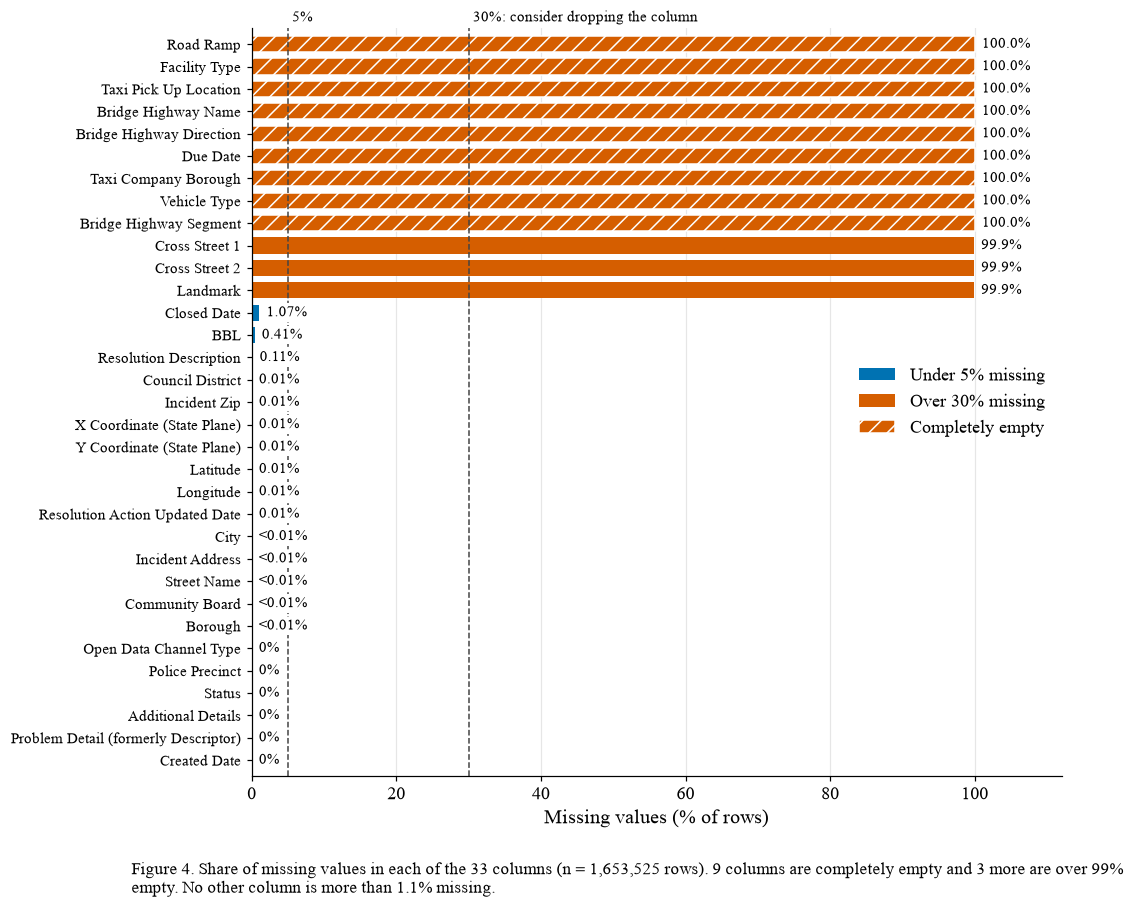

In [44]:
ORANGE = "#E69F00"


def band_colour(percent):
    """Colour by the lecture's three bands: under 5%, 5 to 30%, over 30%."""
    if percent > 30:
        return VERMILION
    if percent >= 5:
        return ORANGE
    return BLUE


names = list(missing_before.index)[::-1]
values = list(missing_before.values)[::-1]

fig, ax = plt.subplots(figsize=(9.5, 8.6))
bars = ax.barh(names, values, color=[band_colour(v) for v in values], height=0.72)

for bar, value in zip(bars, values):
    if value == 100:
        bar.set_hatch("//")
        bar.set_edgecolor("white")
    ax.text(
        value + 1.0,
        bar.get_y() + bar.get_height() / 2,
        percent_label(value),
        va="center",
        fontsize=10,
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.5},
        zorder=4,
    )

for threshold in (5, 30):
    ax.axvline(threshold, color="#444444", linestyle="--", linewidth=1)
ax.text(5.6, 1.005, "5%", transform=ax.get_xaxis_transform(), fontsize=10, va="bottom")
ax.text(30.6, 1.005, "30%: consider dropping the column", transform=ax.get_xaxis_transform(), fontsize=10, va="bottom")

ax.set_xlim(0, 112)
ax.set_ylim(-0.7, len(names) - 0.3)
fig.subplots_adjust(bottom=0.09)
ax.set_xlabel("Missing values (% of rows)")
ax.tick_params(axis="y", labelsize=10)
ax.grid(axis="y", visible=False)
ax.legend(
    handles=[
        Patch(facecolor=BLUE, label="Under 5% missing"),
        Patch(facecolor=VERMILION, label="Over 30% missing"),
        Patch(facecolor=VERMILION, hatch="//", edgecolor="white", label="Completely empty"),
    ],
    loc="center right",
)

n_empty = int((missing_before == 100).sum())
n_sparse = int(((missing_before > 99) & (missing_before < 100)).sum())
others_max = missing_before[missing_before < 99].max()
add_caption(
    fig,
    f"Figure 4. Share of missing values in each of the {columns_total} columns (n = {len(clean):,} rows). "
    f"{n_empty} columns are completely empty and {n_sparse} more are over 99% empty. "
    f"No other column is more than {others_max:.1f}% missing.",
    y=0.0,
)
fig.savefig(FIG_DIR / "04_missing_by_column.png")
plt.show()

**Reading Figure 4.** The columns split into two groups with nothing in between.
Twelve columns are essentially empty: nine are 100% blank, and three (`Cross Street 1`, `Cross Street 2`, `Landmark`) are about 99.9% blank.
Every other column is nearly complete, and none of them is anywhere near the 5% line.

### 6.2 Drop the columns that are completely empty

**Decision.** Drop every column whose values are all missing.

**Why.** A column with no values has nothing to learn from, and nothing can be imputed from nothing.
The nine columns are leftovers from other 311 complaint types (vehicles, taxis, bridges and highways) and have no meaning for a heating request.

In [45]:
all_null_cols = [col for col in clean.columns if clean[col].isna().all()]
columns_before = clean.shape[1]

clean = clean.drop(columns=all_null_cols)

print(f"Dropped {len(all_null_cols)} columns that are completely empty:")
for col in all_null_cols:
    print(f"    {col}")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns (was {columns_before})")

Dropped 9 columns that are completely empty:
    Facility Type
    Due Date
    Vehicle Type
    Taxi Company Borough
    Taxi Pick Up Location
    Bridge Highway Name
    Bridge Highway Direction
    Road Ramp
    Bridge Highway Segment
clean: 1,653,525 rows x 24 columns (was 33)


**Change made:** 9 completely empty columns dropped (`Facility Type`, `Due Date`, `Vehicle Type`, `Taxi Company Borough`,
`Taxi Pick Up Location`, `Bridge Highway Name`, `Bridge Highway Direction`, `Road Ramp`, `Bridge Highway Segment`).
No rows were removed. The 24 remaining columns all contain at least some data.

### 6.3 Drop the columns that are more than 30% missing

**Rule (Lecture 4).** When more than 30% of a column is missing, the column is too incomplete to trust, and imputing it would mostly be inventing data.
The column is dropped. The code finds these columns from the data instead of using a hand-written list.

In [46]:
DROP_THRESHOLD = 30

missing_now = missing_percent(clean)
over_threshold = missing_now[missing_now > DROP_THRESHOLD]
columns_before = clean.shape[1]

print(f"Columns with more than {DROP_THRESHOLD}% missing: {len(over_threshold)}")
over_threshold.rename("missing (%)").round(3)

Columns with more than 30% missing: 3


Cross Street 1    99.891
Cross Street 2    99.890
Landmark          99.890
Name: missing (%), dtype: float64

In [47]:
dropped_for_missing = list(over_threshold.index)
clean = clean.drop(columns=dropped_for_missing)

print(f"Dropped: {dropped_for_missing}")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns (was {columns_before})")

Dropped: ['Cross Street 1', 'Cross Street 2', 'Landmark']
clean: 1,653,525 rows x 21 columns (was 24)


**Change made: 3 columns dropped for being more than 30% missing.**

| Column | Missing | Note |
|---|---|---|
| `Cross Street 1` | 99.89% | filled in only for requests created 10 Aug to 6 Oct 2023 |
| `Cross Street 2` | 99.89% | same window |
| `Landmark` | 99.89% | same window |

Only about 1,810 of 1.65 million rows have a value in any of them, so they could not describe the typical request.
No rows were removed. `clean` now has 21 columns.

### 6.4 Columns that still have missing values

Nothing is dropped or filled here. This table lists every remaining column with a missing value, with the number of rows affected.

In [48]:
missing_table = pd.DataFrame(
    {
        "type": clean.dtypes.astype(str),
        "missing rows": clean.isna().sum(),
        "missing (%)": (clean.isna().mean() * 100).round(4),
    }
)
missing_table = missing_table[missing_table["missing rows"] > 0].sort_values("missing rows", ascending=False)
missing_table.index.name = "column"

complete = [col for col in clean.columns if col not in missing_table.index]
print(f"{len(missing_table)} of {clean.shape[1]} columns have missing values. Complete columns: {complete}")

missing_table.style.format({"missing rows": "{:,}", "missing (%)": "{:.4f}"})

15 of 21 columns have missing values. Complete columns: ['Created Date', 'Problem Detail (formerly Descriptor)', 'Additional Details', 'Status', 'Police Precinct', 'Open Data Channel Type']


,type,missing rows,missing (%)
column,,,
Closed Date,datetime64[us],"17,654",1.0677
BBL,str,"6,795",0.4109
Resolution Description,str,"1,864",0.1127
Incident Zip,str,190,0.0115
Council District,str,190,0.0115
X Coordinate (State Plane),float64,188,0.0114
Y Coordinate (State Plane),float64,188,0.0114
Latitude,float64,188,0.0114
Longitude,float64,188,0.0114


### 6.5 Drop the open requests (missing target)

**Rule (Lecture 4, slide 29).** For the target variable, drop the rows where it is missing, because a model cannot be trained on answers that do not exist.

Here the target is the time between `Created Date` and `Closed Date`. `Closed Date` is blank exactly when a request has not closed yet,
so these rows have no resolution time. First, a check that the blanks really are the open requests:

In [49]:
open_mask = clean["Closed Date"].isna()
status_of_open = clean.loc[open_mask, "Status"].value_counts()

print(f"Rows with no Closed Date: {int(open_mask.sum()):,} ({open_mask.mean() * 100:.2f}% of rows)")
print()
print("Status of those rows:")
print(status_of_open.to_string())
print()
print(f"Rows with a Closed Date whose Status is Open or In Progress: {int((~open_mask & clean['Status'].isin(['Open', 'In Progress'])).sum())}")

Rows with no Closed Date: 17,654 (1.07% of rows)

Status of those rows:
Status
Open           17481
In Progress      173

Rows with a Closed Date whose Status is Open or In Progress: 0


**Decision.** Drop every request with no `Closed Date`. All of them are `Open` or `In Progress`, and no closed request is missing the date.

**Why this needs a figure.** The open requests are not a random sample. They are mostly recent, so dropping them removes the requests
that had not had time to close. The figure shows how large that effect is and whether the rest of the data changes shape.

In [50]:
# Summaries of the data before the drop, for the figure.
created_year_before = clean["Created Year"] if "Created Year" in clean.columns else clean["Created Date"].dt.year

open_by_year = pd.DataFrame(
    {
        "all requests": created_year_before.value_counts().sort_index(),
        "open requests": created_year_before[open_mask].value_counts().sort_index(),
    }
).fillna(0)
open_by_year["open (%)"] = open_by_year["open requests"] / open_by_year["all requests"] * 100

BOROUGHS = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
borough_before = clean["Borough"].value_counts(normalize=True).reindex(BOROUGHS) * 100
detail_before = clean["Additional Details"].str.upper().value_counts(normalize=True) * 100

rows_before_open_drop = len(clean)
open_by_year.round(2)

,all requests,open requests,open (%)
Created Date,,,
2020,164573,149,0.09
2021,199148,168,0.08
2022,263693,324,0.12
2023,230973,302,0.13
2024,264410,2967,1.12
2025,315479,1532,0.49
2026,215249,12212,5.67


In [51]:
clean = clean[~open_mask].reset_index(drop=True)

borough_after = clean["Borough"].value_counts(normalize=True).reindex(BOROUGHS) * 100
detail_after = clean["Additional Details"].str.upper().value_counts(normalize=True) * 100

n_open_dropped = int(open_mask.sum())
assert clean["Closed Date"].notna().all()
assert rows_before_open_drop - len(clean) == n_open_dropped
print(f"{rows_before_open_drop:,} rows -> {len(clean):,} rows (removed {n_open_dropped:,} open requests)")

1,653,525 rows -> 1,635,871 rows (removed 17,654 open requests)


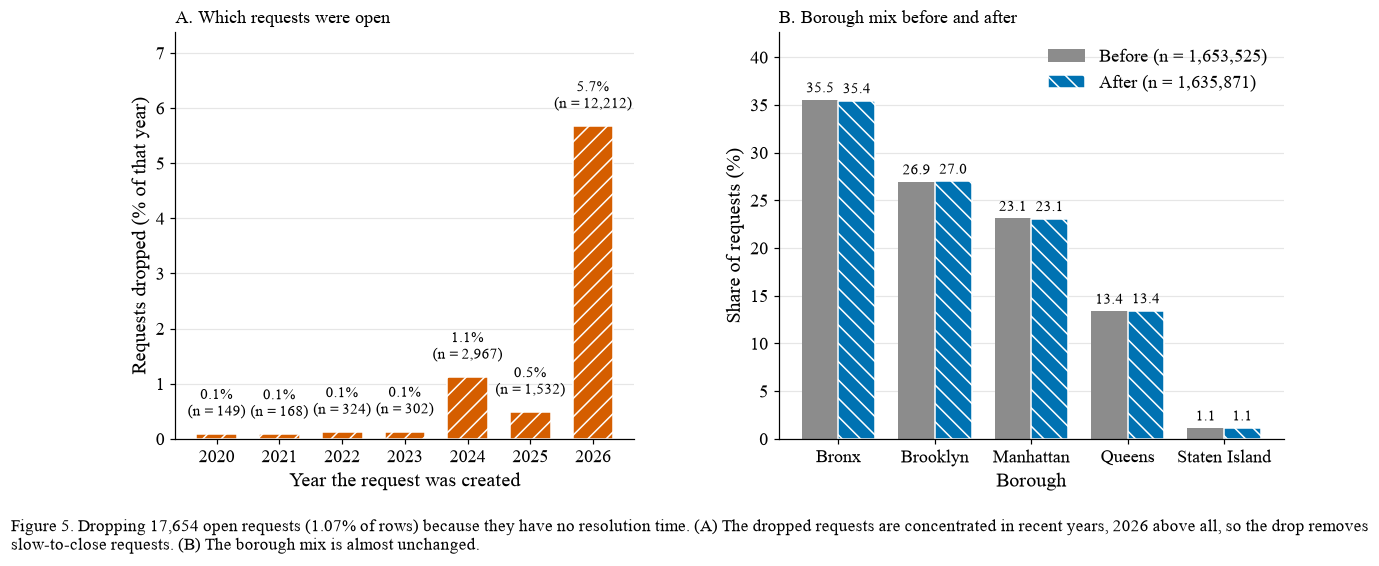

In [52]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1, 1.1], "wspace": 0.3})

# Panel A: what share of each year's requests were dropped. Zero baseline.
years = open_by_year.index.to_list()
shares = open_by_year["open (%)"].to_list()
bars = ax_a.bar([str(year) for year in years], shares, color=VERMILION, hatch="//", edgecolor="white", width=0.65)
for bar, share, year in zip(bars, shares, years):
    count = int(open_by_year.loc[year, "open requests"])
    ax_a.text(bar.get_x() + bar.get_width() / 2, share + 0.25, f"{share:.1f}%\n(n = {count:,})", ha="center", va="bottom", fontsize=10)

ax_a.set_ylim(0, max(shares) * 1.3)
ax_a.set_xlabel("Year the request was created")
ax_a.set_ylabel("Requests dropped (% of that year)")
ax_a.grid(axis="x", visible=False)
ax_a.set_title("A. Which requests were open", loc="left", fontsize=12)

# Panel B: borough mix before and after, same zero baseline.
positions = np.arange(len(BOROUGHS))
bar_width = 0.38
ax_b.bar(positions - bar_width / 2, borough_before.values, bar_width, color=GREY)
ax_b.bar(positions + bar_width / 2, borough_after.values, bar_width, color=BLUE, hatch="\\\\", edgecolor="white")
for pos, before_value, after_value in zip(positions, borough_before.values, borough_after.values):
    ax_b.text(pos - bar_width / 2, before_value + 0.8, f"{before_value:.1f}", ha="center", fontsize=10)
    ax_b.text(pos + bar_width / 2, after_value + 0.8, f"{after_value:.1f}", ha="center", fontsize=10)

ax_b.set_xticks(positions)
ax_b.set_xticklabels([name.title() for name in BOROUGHS])
ax_b.set_ylim(0, borough_before.max() * 1.2)
ax_b.set_ylabel("Share of requests (%)")
ax_b.set_xlabel("Borough")
ax_b.grid(axis="x", visible=False)
ax_b.set_title("B. Borough mix before and after", loc="left", fontsize=12)
ax_b.legend(
    handles=[
        Patch(facecolor=GREY, label=f"Before (n = {rows_before_open_drop:,})"),
        Patch(facecolor=BLUE, hatch="\\\\", edgecolor="white", label=f"After (n = {len(clean):,})"),
    ],
    loc="upper right",
)

add_caption(
    fig,
    f"Figure 5. Dropping {n_open_dropped:,} open requests ({n_open_dropped / rows_before_open_drop * 100:.2f}% of rows) because they have no resolution time. "
    f"(A) The dropped requests are concentrated in recent years, 2026 above all, so the drop removes slow-to-close requests. "
    f"(B) The borough mix is almost unchanged.",
)
fig.savefig(FIG_DIR / "05_open_requests_dropped.png")
plt.show()

In [53]:
mix_change = pd.DataFrame({"before (%)": detail_before, "after (%)": detail_after})
mix_change["change (points)"] = mix_change["after (%)"] - mix_change["before (%)"]
mix_change.round(2)

,before (%),after (%),change (points)
Additional Details,,,
NO HEAT,57.86,57.91,0.05
NO HEAT AND NO HOT WATER,25.70,25.71,0.01
NO HOT WATER,16.10,16.03,-0.06
HEAT ON IN SUMMER,0.34,0.35,0.00


**Reading Figure 5.**
- **(A)** Open requests are rare in 2020 to 2023 (about 0.1% each year), then rise to 1.1% in 2024, 0.5% in 2025 and 5.7% in 2026. 2026 holds 12,212 of the 17,654 dropped rows.
  The requests dropped are the ones with the least time to close, so the drop removes slow cases and the target will read slightly faster than reality.
  The year is therefore not a neutral feature, which adds to the case for a time-based train/test split.
- **(B)** The borough mix moves by a fraction of a point, and the table shows the same for the type of problem. Apart from time, the dropped rows look like the rest.

**Change made: 17,654 rows dropped** (all `Open` or `In Progress`). Every remaining request has a `Closed Date`, so the target can be computed for all of them.
`clean` is now 1,635,871 rows by 21 columns. No columns were removed.

## 7. Cleaning step 4: packed and indirect fields

**Question this step answers:** *Does any column hold more than one piece of information, or hold information that only appears once it is computed from other columns?*

The one you expected is the **resolution time**: nothing stores it, but it is the difference between two timestamps.
It is the target, so it is created first.

### 7.1 Create the resolution time (the target)

**Definition.** `Resolution Hours` = `Closed Date` minus `Created Date`, in hours.

Hours fit this data: the median request takes about 43 hours, and 99% finish within a week, so days would be too coarse and minutes too fine.
Every remaining request has both timestamps (the open requests were dropped in 6.5), so every row gets a value.
The new column is only *created* here. Negative values and extreme values are handled in the target-cleaning step.

In [54]:
TARGET = "Resolution Hours"

if TARGET not in clean.columns:
    elapsed = clean["Closed Date"] - clean["Created Date"]
    clean[TARGET] = elapsed.dt.total_seconds() / 3600

target = clean[TARGET]
print(f"{TARGET} created: {target.notna().sum():,} values, {target.isna().sum():,} blank")
print(f"clean: {clean.shape[0]:,} rows x {clean.shape[1]} columns")

Resolution Hours created: 1,635,871 values, 0 blank
clean: 1,635,871 rows x 22 columns


In [55]:
target.describe().to_frame(TARGET).T

,count,mean,std,min,25%,50%,75%,max
Resolution Hours,1635871.0,50.916073,192.969888,-20.312222,23.654722,42.841389,66.979167,33938.543889


In [56]:
print(f"Negative (closed before created): {(target < 0).sum():,}")
print(f"Zero (closed at the same instant): {(target == 0).sum():,}")
print(f"Over 30 days:                      {(target > 24 * 30).sum():,}")
print(f"Over 1 year:                       {(target > 24 * 365).sum():,}")

Negative (closed before created): 184
Zero (closed at the same instant): 107
Over 30 days:                      443
Over 1 year:                       115


**Change made: 1 column created, `Resolution Hours` (float64, hours).**

The mean (about 51 hours) sits above the median (about 43 hours), and the maximum is about 34,000 hours (nearly four years), so the distribution has a long right tail.
The counts above also show the impossible values waiting for the target-cleaning step: negative values, zeros, and very long durations.
No rows were removed.

### 7.2 Calendar fields packed inside `Created Date`

A timestamp holds several facts at once: the year, the month and the day of the week. A model cannot use them until they are separated,
and the target depends on all three (checked on requests resolved within 30 days):

- **Weekday.** Requests filed on a Friday or Saturday take about 16 hours longer (median about 51 h) than ones filed on a Tuesday (about 35 h).
  This is the clearest pattern, and it is not just winter demand.
- **Month.** It is not a simple winter effect. March to May is fastest (about 32 h) and December and January are slowest (about 48 h).
  A heating-season flag (October to May) separates only 40.2 h from 43.0 h, so the month is used instead of a flag.
- **Year.** Resolution time shifts between years (about 36 h in 2024, about 49 h in 2021).
  So the train/test split should be by time, and year cannot be treated as a clean feature.

Hour of day was left out on purpose; it shows a weaker signal.

In [57]:
clean["Created Year"] = clean["Created Date"].dt.year
clean["Created Month"] = clean["Created Date"].dt.month
clean["Created Weekday"] = clean["Created Date"].dt.day_name()

clean[["Created Date", "Created Year", "Created Month", "Created Weekday"]].head()

,Created Date,Created Year,Created Month,Created Weekday
0,2026-10-01 17:53:22,2026,10,Thursday
1,2026-10-01 17:40:17,2026,10,Thursday
2,2026-10-01 17:05:48,2026,10,Thursday
3,2026-10-01 16:40:26,2026,10,Thursday
4,2026-10-01 15:05:30,2026,10,Thursday


In [58]:
WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

check = clean.dropna(subset=[TARGET])
check = check[(check[TARGET] > 0) & (check[TARGET] < 24 * 30)]

by_weekday = check.groupby("Created Weekday")[TARGET].median().reindex(WEEKDAY_ORDER)
by_month = check.groupby("Created Month")[TARGET].median()
by_year = check.groupby("Created Year")[TARGET].median()

pd.DataFrame({"median hours by weekday": by_weekday.round(1)})

,median hours by weekday
Created Weekday,
Monday,40.4
Tuesday,34.9
Wednesday,35.1
Thursday,40.9
Friday,51.3
Saturday,51.3
Sunday,43.7


In [59]:
pd.DataFrame({"median hours by month": by_month.round(1)}).T

Created Month,1,2,3,4,5,6,7,8,9,10,11,12
median hours by month,47.9,43.8,32.2,31.8,31.7,34.4,43.3,42.9,41.0,38.1,45.8,48.4


In [60]:
pd.DataFrame({"median hours by year": by_year.round(1)}).T

Created Year,2020,2021,2022,2023,2024,2025,2026
median hours by year,46.6,49.3,49.0,38.4,36.4,39.4,43.9


**Change made: 3 columns created from `Created Date`.**

| New column | Values | Meaning |
|---|---|---|
| `Created Year` | 2020 to 2026 | year the request was filed |
| `Created Month` | 1 to 12 | month the request was filed |
| `Created Weekday` | Monday to Sunday | day of the week the request was filed |

The tables above confirm the pattern behind each one. The medians are computed only on requests resolved within 30 days, to keep the long tail from hiding the pattern.
No rows were removed.

## 8. Shape of the cleaned dataset (so far)

In [61]:
print(f"Raw file:           22,671,531 rows x 44 columns")
print(f"Heating only:       {heating.shape[0]:,} rows x {heating.shape[1]} columns")
print(f"Cleaned so far:     {clean.shape[0]:,} rows x {clean.shape[1]} columns")
print(f"Rows removed since filtering to heating: {heating.shape[0] - clean.shape[0]:,} ({n_duplicates:,} duplicates + {n_open_dropped:,} open requests)")

Raw file:           22,671,531 rows x 44 columns
Heating only:       1,656,653 rows x 44 columns
Cleaned so far:     1,635,871 rows x 25 columns
Rows removed since filtering to heating: 20,782 (3,128 duplicates + 17,654 open requests)


In [62]:
shape_summary = pd.DataFrame(
    {
        "dtype": clean.dtypes.astype(str),
        "missing rows": clean.isna().sum(),
        "distinct values": clean.nunique(),
    }
)
shape_summary.index.name = "column"
shape_summary

,dtype,missing rows,distinct values
column,,,
Created Date,datetime64[us],0,1558684
Closed Date,datetime64[us],0,553427
Problem Detail (formerly Descriptor),str,0,5
Additional Details,str,0,8
Incident Zip,str,186,209
Incident Address,str,3,99808
Street Name,str,3,5034
City,str,148,89
Status,str,0,2


### How the columns got from 44 to 25

| Step | Columns | Change |
|---|---|---|
| Heating only (section 2) | 44 | start |
| ID dropped (4.1) | 43 | -1: `Unique Key` |
| Single-value columns (4.3) | 39 | -4: `Agency`, `Agency Name`, `Park Facility Name`, `Problem` |
| Copy columns (4.4) | 36 | -3: `Intersection Street 1`, `Intersection Street 2`, `Park Borough` |
| `Address Type`, `Location`, `Location Type` (4.5 to 4.7) | 33 | -3 |
| Completely empty (6.2) | 24 | -9 |
| Over 30% missing (6.3) | 21 | -3: `Cross Street 1`, `Cross Street 2`, `Landmark` |
| Open requests dropped (6.5) | 21 | no column change; 17,654 rows removed |
| Resolution time created (7.1) | 22 | +1: `Resolution Hours` |
| Calendar fields created (7.2) | 25 | +3: `Created Year`, `Created Month`, `Created Weekday` |

Rows went from 1,656,653 to 1,635,871 (3,128 exact duplicates and 17,654 open requests removed). Still to do: impossible and extreme target values,
the remaining small gaps, and the text stand-ins for missing values.

## 9. Decision table: every cleaning change

The output of an EDA is a table of decisions (Lecture 4): for each column or issue, what was decided and why.
This table covers every change made so far, in the order it was made, so a reader can pick up the data without asking the authors anything.

| Column / issue | Decision | Because |
|---|---|---|
| Rows from the 260 other complaint categories | keep only `HEAT/HOT WATER`; 22,671,531 rows down to 1,656,653 | the project predicts heating resolution time only; other categories have other agencies and processes. Matching on the upper-cased label keeps the 1,814 rows spelled `Heat/Hot Water`. |
| `Unique Key` | drop the column | a row ID; it also made `duplicated()` return 0 (3,128 without it) |
| Duplicate rows | drop 3,128 exact copies, keep the first | only visible once the ID was removed; 70% came from the mobile app (double-taps); the target distribution did not move |
| `Agency`, `Agency Name`, `Park Facility Name`, `Problem` | drop 4 columns | one value in every row (`Problem` had two spellings but one value once upper-cased) |
| `Intersection Street 1`, `Intersection Street 2`, `Park Borough` | drop 3 columns | identical to `Cross Street 1`, `Cross Street 2` and `Borough` in all 1,653,525 rows |
| `Address Type` | drop the column | `ADDRESS` in 1,653,522 of 1,653,525 rows (99.9998%) |
| `Location` | drop the column | the text `POINT (lon lat)`; equals `Longitude` and `Latitude` to within 5e-12 degrees |
| `Location Type` | drop the column | `RESIDENTIAL BUILDING` in 99.89% of rows; in the rest it only repeats `Problem Detail` |
| `Latitude`, `Longitude`, `X Coordinate (State Plane)`, `Y Coordinate (State Plane)` | strip thousands commas, cast to float64 | stored as text, so `describe()` skipped them (0 numeric columns before, 4 after) |
| `Created Date`, `Closed Date`, `Resolution Action Updated Date` | cast to datetime64 with the exact format | stored as text; text dates sort alphabetically, and the target cannot be computed from text |
| `Incident Zip`, `Council District`, `BBL` | keep as text | labels for a place, not measurements; `Council District` has leading zeros |
| 9 empty columns (`Facility Type`, `Due Date`, `Vehicle Type`, `Taxi Company Borough`, `Taxi Pick Up Location`, `Bridge Highway Name`, `Bridge Highway Direction`, `Road Ramp`, `Bridge Highway Segment`) | drop | 100% missing; leftovers from other 311 complaint types |
| `Cross Street 1`, `Cross Street 2`, `Landmark` | drop | 99.89% missing (over the 30% rule); filled only for requests created 10 Aug to 6 Oct 2023 |
| 17,654 requests with no `Closed Date` | drop the rows | the target is missing, and a target is never imputed. All are `Open` or `In Progress`. 12,212 are from 2026, so the drop removes slow-to-close requests, and borough and problem-type mix barely move. |
| Resolution time | create `Resolution Hours` = `Closed Date` minus `Created Date`, in hours | it is the target; median 42.8 h, mean 50.9 h, long right tail |
| Seasonality and time trend | create `Created Year`, `Created Month`, `Created Weekday` from `Created Date` | median resolution time varies with each: Friday and Saturday about 16 h slower than Tuesday; March to May fastest; year shifts (36 h in 2024, 49 h in 2021) |

In [63]:
DROPPED_FROM_RAW = {
    "Unique Key",
    "Agency", "Agency Name", "Park Facility Name", "Problem (formerly Complaint Type)",
    "Intersection Street 1", "Intersection Street 2", "Park Borough",
    "Address Type", "Location", "Location Type",
    "Facility Type", "Due Date", "Vehicle Type", "Taxi Company Borough", "Taxi Pick Up Location",
    "Bridge Highway Name", "Bridge Highway Direction", "Road Ramp", "Bridge Highway Segment",
    "Cross Street 1", "Cross Street 2", "Landmark",
}
CREATED = {"Resolution Hours", "Created Year", "Created Month", "Created Weekday"}

actually_dropped = set(heating.columns) - set(clean.columns)
actually_created = set(clean.columns) - set(heating.columns)

# The table above must match what the notebook really did.
assert actually_dropped == DROPPED_FROM_RAW
assert actually_created == CREATED

print(f"Columns dropped: {len(actually_dropped)}    Columns created: {len(actually_created)}")
print(f"Columns: {heating.shape[1]} - {len(actually_dropped)} + {len(actually_created)} = {clean.shape[1]}")
print(f"Rows: {heating.shape[0]:,} - {n_duplicates:,} duplicates - {n_open_dropped:,} open requests = {clean.shape[0]:,}")

Columns dropped: 23    Columns created: 4
Columns: 44 - 23 + 4 = 25
Rows: 1,656,653 - 3,128 duplicates - 17,654 open requests = 1,635,871


### Not yet decided

These are known and still open, so the table above is not the final one.

| Column / issue | Why it is open |
|---|---|
| 184 negative and 107 zero `Resolution Hours` | closed before or at the instant of creation; impossible |
| 443 values over 30 days (115 over a year) | extreme tail; entry errors or genuine long cases |
| Small gaps (`BBL` 6,738 rows, location columns 186, and a few more) | the slide allows dropping or simple imputation below 5% missing |
| "Unspecified" in `Police Precinct`, `Community Board`, `Borough`, `Status` | text standing in for a missing value |
| `Problem Detail`, `Additional Details` spelled in two cases | the same category counted twice |
| `Closed Date`, `Status`, `Resolution Description`, `Resolution Action Updated Date` | only known after resolution, so they must not be features |

## 10. Save the cleaned dataset

The cleaned heating data is saved so charts can be built from it without re-running the cleaning (the raw file takes about 90 seconds to scan).

- `data/heating_clean.parquet` keeps every column type exactly (datetimes, floats, text). Use this in Python.
- `data/heating_clean.csv` is the same data for Tableau, with dates written as `YYYY-MM-DD HH:MM:SS`.

In [64]:
CLEAN_PARQUET = DATA_DIR / "heating_clean.parquet"
CLEAN_CSV = DATA_DIR / "heating_clean.csv"

clean.to_parquet(CLEAN_PARQUET, index=False)
clean.to_csv(CLEAN_CSV, index=False, date_format="%Y-%m-%d %H:%M:%S")

for path in (CLEAN_PARQUET, CLEAN_CSV):
    print(f"{path}: {path.stat().st_size / 1e6:,.0f} MB")

data/heating_clean.parquet: 72 MB
data/heating_clean.csv: 954 MB


In [65]:
# Read the parquet file back and confirm nothing changed on the way to disk.
reloaded = pd.read_parquet(CLEAN_PARQUET)

assert reloaded.shape == clean.shape
assert list(reloaded.columns) == list(clean.columns)
assert (reloaded.dtypes.astype(str) == clean.dtypes.astype(str)).all()
assert reloaded["Resolution Hours"].equals(clean["Resolution Hours"])

print(f"Saved and verified: {reloaded.shape[0]:,} rows x {reloaded.shape[1]} columns")

Saved and verified: 1,635,871 rows x 25 columns
